In [2]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 46.1 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=28afc46fe29a28a0f3e9411b52dc4be4f12620286f8cd5e872f6d069fc529e19
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Muntatge de Google Drive
Muntatge de Google Drive per accedir als fitxers del projecte.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Definició de rutes
Definició de les rutes d’imatges i del fitxer de metadades


In [4]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


### Càrrega i balanç de classes
Càrrega de les metadades, construcció de les rutes d’imatge i càlcul del nombre de mostres negatives i positives.


In [5]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


### Verificació del dataset
Comprovació de rutes d’imatge, inspecció inicial de les dades i anàlisi del balanç


In [6]:
import pandas as pd
import os

# Cargar metadata
df = pd.read_csv(PATH_METADATA)

# Crear nueva ruta hacia PNG
df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

# Mostrar primeras filas con información relevante
print(df[["img_name", "file_path"]].head())

# Verificar si las rutas son válidas
print("\nVerificando existencia de archivos PNG:")

for i in range(5):  # probar las 5 primeras rutas
    fp = df.loc[i, "file_path"]
    exists = os.path.exists(fp)
    print(f"{fp} → {'OK' if exists else 'NO ENCONTRADO'}")

# Contar positivos y negativos
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("\nResumen:")
print("Negativos:", num_neg)
print("Positivos:", num_pos)


    img_name                                          file_path
0  n0239.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
1  n0342.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
2  n0996.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
3  n0418.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
4  n0538.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...

Verificando existencia de archivos PNG:
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0239.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0996.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0418.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0538.png → OK

Resumen:
Negativos: 3748
Positivos: 4427


### Bloc SE (Squeeze-and-Excitation)
Implementació d’un mòdul d’atenció de canals que recalibra les característiques mitjançant *global average pooling*.


### Dataset NODE21
Dataset de PyTorch per a detecció que carrega imatges PNG, les normalitza a tres canals i genera les bounding boxes i etiquetes associades.


In [8]:
from torch.utils.data import Dataset, DataLoader
class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        self.df = df.copy()
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

        # UNA entrada por imagen
        self.images = self.df["file_path"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        # Cargar imagen
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # 3 canales
        img3 = np.stack([img, img, img], axis=0)

        # Todas las anotaciones de esa imagen
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return torch.tensor(img3, dtype=torch.float32), target

### Visualització d’anotacions
Visualització d’una imatge del dataset amb les bounding boxes dels nòduls superposades.


Mostrando: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png


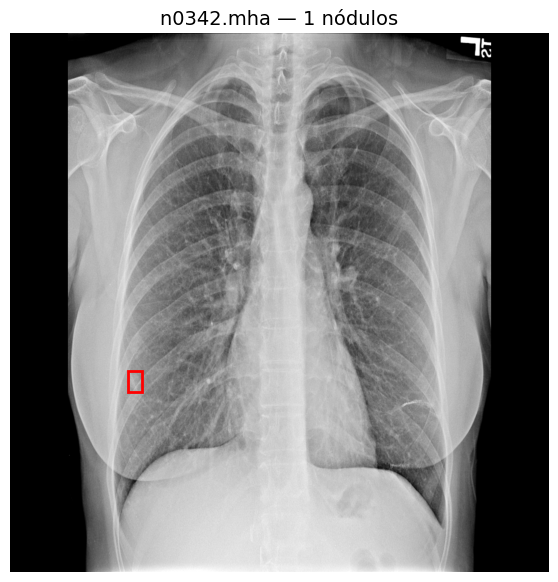

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

def show_png_with_boxes(df, idx):
    # Obtener ruta y nombre del archivo
    path = df.loc[idx, "file_path"]
    img_name = df.loc[idx, "img_name"]
    print("Mostrando:", path)

    # Cargar imagen PNG
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("ERROR: No se pudo cargar la imagen")
        return

    # Normalización para visualización
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Obtener todas las anotaciones de esta imagen
    rows = df[df["file_path"] == path]

    boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            boxes.append((x1, y1, x2, y2))

    # ------------------------------
    #  VISUALIZACIÓN
    # ------------------------------
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{img_name} — {len(boxes)} nódulos", fontsize=14)

    # Dibujar cada bounding box
    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis("off")
    plt.show()
show_png_with_boxes(df, 1)

### Visualització multicanal amb anotacions
Funció per visualitzar els tres canals d’entrada (original, CLAHE i *unsharp mask*) amb les bounding boxes dels nòduls superposades, per validar el preprocessament multicanal.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

def show_png_multichannel_with_boxes(df, idx):
    path = df.loc[idx, "file_path"]
    img_name = df.loc[idx, "img_name"]
    print("Mostrando:", path)

    # ---------------------------
    # 1. Cargar imagen base
    # ---------------------------
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("ERROR: No se pudo cargar la imagen")
        return

    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # ---------------------------
    # 2. Canales 
    # ---------------------------
    ch1 = img

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    ch2 = clahe.apply((img * 255).astype(np.uint8)).astype(np.float32) / 255.0

    blur = cv2.GaussianBlur(img, (5,5), 1.0)
    ch3 = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    ch3 = np.clip(ch3, 0.0, 1.0)

    channels = [ch1, ch2, ch3]
    titles = ["Canal 1: Original", "Canal 2: CLAHE", "Canal 3: Unsharp Mask"]

    # ---------------------------
    # 3. Bounding boxes
    # ---------------------------
    rows = df[df["file_path"] == path]
    boxes = []

    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            boxes.append((x1, y1, x2, y2))

    # ---------------------------
    # 4. Visualización
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, ch, title in zip(axes, channels, titles):
        ax.imshow(ch, cmap="gray")
        ax.set_title(title, fontsize=12)

        for (x1, y1, x2, y2) in boxes:
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

        ax.axis("off")

    fig.suptitle(f"{img_name} — {len(boxes)} nódulos", fontsize=14)
    plt.tight_layout()
    plt.show()


Mostrando: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png


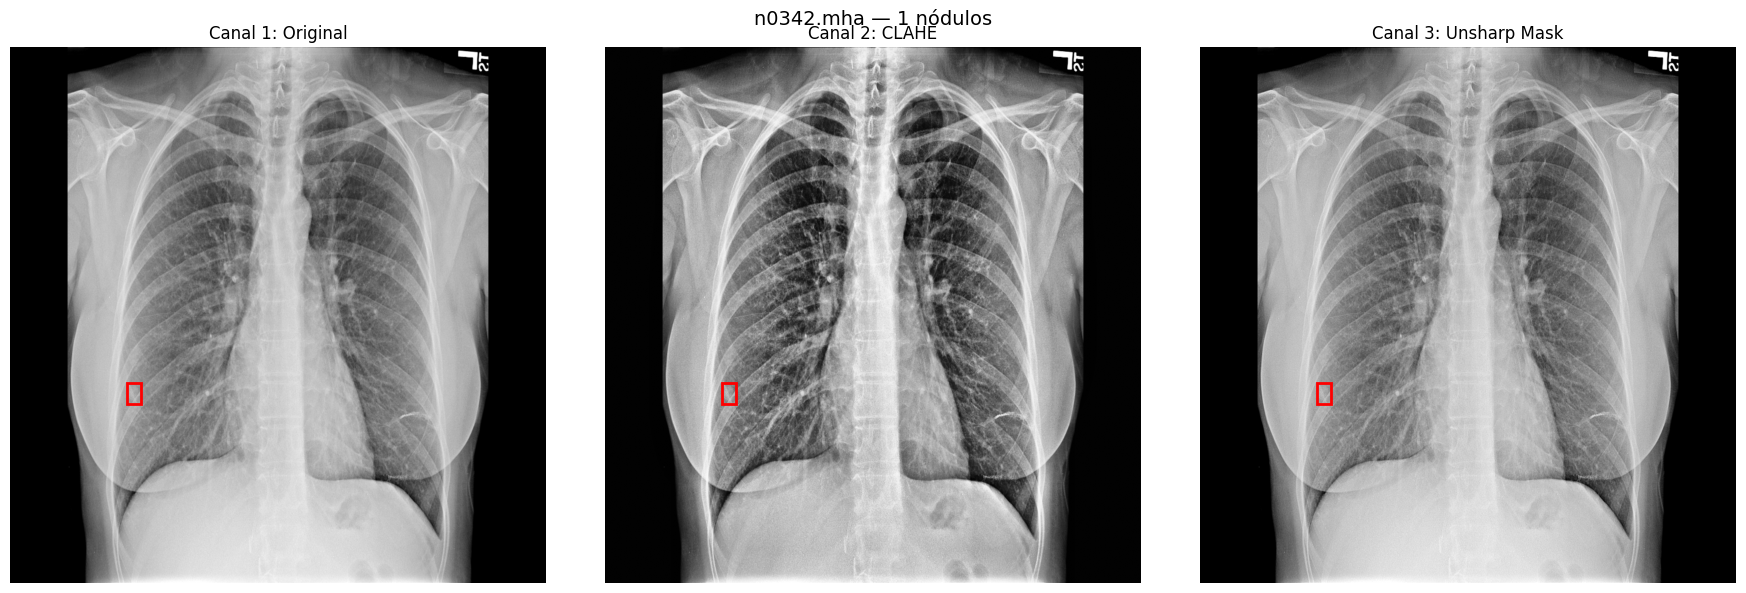

In [ ]:
show_png_multichannel_with_boxes(df, 1)


In [11]:
import cv2
import numpy as np
import torch
dataset = Node21DetectionDatasetPNG(df)

img, target = dataset[1]

print(img.shape)
print(target)

torch.Size([3, 1024, 1024])
{'boxes': tensor([[223., 642., 250., 682.]]), 'labels': tensor([1]), 'area': tensor([1080.]), 'iscrowd': tensor([0]), 'image_id': tensor([1])}


In [12]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

# 2. Split
from sklearn.model_selection import train_test_split

images = df["file_path"].unique()

train_imgs, val_imgs = train_test_split(
    images, test_size=0.2, random_state=42
)

train_df = df[df["file_path"].isin(train_imgs)]
val_df   = df[df["file_path"].isin(val_imgs)]

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

### Preparació dels DataLoaders
Definició del `collate_fn`, divisió del dataset en entrenament i validació per imatge i creació dels DataLoader corresponents.


In [ ]:
for imgs, targets in train_loader:
    print("Batch size:", len(imgs))
    print("Image shape:", imgs[0].shape)
    print("Targets:", targets[0])
    break

Batch size: 2
Image shape: torch.Size([3, 1024, 1024])
Targets: {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64), 'image_id': tensor([1113])}


### Bloc SE 1D
Implementació d’un mòdul *Squeeze-and-Excitation* 1D que recalibra característiques a nivell de canals mitjançant atenció.


In [26]:
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        # x: [N, C]
        w = F.relu(self.fc1(x))
        w = torch.sigmoid(self.fc2(w))
        return x * w


### Capçal ROI amb atenció
Definició d’un capçal de regions que integra un mòdul d’atenció SE 1D sobre el `box_head` per millorar la representació de les característiques.


In [27]:
class ROIBoxHeadWithAttention(nn.Module):
    def __init__(self, box_head):
        super().__init__()
        self.box_head = box_head          # TwoMLPHead ORIGINAL
        self.attn = SEBlock1D(1024)       # atención vectorial

    def forward(self, x):
        x = self.box_head(x)              # [N, 1024]
        x = self.attn(x)                  # [N, 1024]
        return x




### Faster R-CNN amb atenció al ROI
Inicialització del Faster R-CNN amb pesos VinDr, integració d’un mòdul d’atenció SE al capçal ROI, congelació parcial del backbone i definició del capçal final adaptat al dataset NODE21.


In [28]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/fastercnn50_vindr.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Crear modelo base
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

# Cargar pesos VinDR
state_dict = torch.load(MODEL_PATH, map_location=device)

# Eliminar head VinDR (15 clases)
keys_to_remove = [
    "roi_heads.box_predictor.cls_score.weight",
    "roi_heads.box_predictor.cls_score.bias",
    "roi_heads.box_predictor.bbox_pred.weight",
    "roi_heads.box_predictor.bbox_pred.bias",
]

for k in keys_to_remove:
    if k in state_dict:
        del state_dict[k]

model.load_state_dict(state_dict, strict=False)
old_roi = model.roi_heads
old_roi.box_head = ROIBoxHeadWithAttention(old_roi.box_head)

# Congelar todo el backbone primero
for param in model.backbone.body.parameters():
    param.requires_grad = False

# Descongelar layer4 (capas más profundas)
for name, param in model.backbone.body.named_parameters():
    if name.startswith("layer4"):
        param.requires_grad = True

# Dejar FPN entrenable
for name, param in model.backbone.named_parameters():
    if "fpn" in name:
        param.requires_grad = True

# Head Node21 (2 clases)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Device + train
model.to(device)
model.train()

print("Modelo Faster R-CNN VinDR listo para entrenamiento (layer4 + FPN entrenables).")


Modelo Faster R-CNN VinDR listo para entrenamiento (layer4 + FPN entrenables).


### Entrenament d’una època
Funció que executa una època d’entrenament del model, calcula les pèrdues, actualitza els pesos i mostra el progrés del procés.


In [29]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward + cálculo de pérdidas
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        # --- protección frente a NaNs / Infs ---
        if not torch.isfinite(loss):
            print("Loss no finita detectada, batch omitido")
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # --- mostrar pérdidas individuales ---
        loop.set_postfix({
            "total": f"{loss.item():.3f}",
            "cls": f"{loss_dict['loss_classifier'].item():.3f}",
            "box": f"{loss_dict['loss_box_reg'].item():.3f}",
            "rpn": f"{loss_dict['loss_objectness'].item():.3f}"
        })

    return total_loss / len(loader)

### Avaluació d’una època
Funció que avalua el model sobre el conjunt de validació i calcula la pèrdua mitjana sense actualitzar els pesos.


In [30]:
from tqdm import tqdm
import torch

def evaluate_one_epoch(model, loader, device):

    model.train()
    total_loss = 0.0

    loop = tqdm(loader, desc="Validando", leave=True)

    with torch.no_grad():
        for images, targets in loop:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            # --- protección ante NaNs / Infs ---
            if not torch.isfinite(loss):
                print("Loss no finita en validación, batch omitido")
                continue

            total_loss += loss.item()

            # --- mostrar pérdidas individuales ---
            loop.set_postfix({
                "total": f"{loss.item():.3f}",
                "cls": f"{loss_dict['loss_classifier'].item():.3f}",
                "box": f"{loss_dict['loss_box_reg'].item():.3f}",
                "rpn": f"{loss_dict['loss_objectness'].item():.3f}"
            })

    return total_loss / len(loader)

### Early stopping
Implementació d’un mecanisme d’aturada anticipada basat en la pèrdua de validació per evitar el sobreentrenament.


In [31]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

        return False


### Bucle principal d’entrenament
Execució de l’entrenament i validació per èpoques, amb guardat de checkpoints, selecció del millor model i aplicació d’early stopping.


In [32]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 40
early_stopper = EarlyStopping(patience=15, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    # Guardar checkpoint por epoch 
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_1canal_frcnn_vindn_attention_roi_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_frcnn_3canal_frcnn_vindn_attention_roi_vindn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break

Run ID: 20251231_231242

===== Epoch 1/40 =====


Validando: 100%|██████████| 715/715 [06:26<00:00,  1.85it/s, total=0.211, cls=0.077, box=0.119, rpn=0.006]


Epoch 1:
  → Train Loss: 0.1003
  → Val Loss:   0.0959
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/40 =====


Validando: 100%|██████████| 715/715 [02:01<00:00,  5.91it/s, total=0.162, cls=0.055, box=0.097, rpn=0.003]


Epoch 2:
  → Train Loss: 0.0850
  → Val Loss:   0.0883
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 3/40 =====


...

Epoch 16:
  → Train Loss: 0.0330
  → Val Loss:   0.1938

===== Epoch 17/40 =====


Validando: 100%|██████████| 715/715 [01:59<00:00,  6.00it/s, total=0.078, cls=0.016, box=0.057, rpn=0.002]


Epoch 17:
  → Train Loss: 0.0333
  → Val Loss:   0.1384

===== Epoch 18/40 =====


Validando: 100%|██████████| 715/715 [01:59<00:00,  5.98it/s, total=0.090, cls=0.021, box=0.064, rpn=0.002]


Epoch 18:
  → Train Loss: 0.0294
  → Val Loss:   0.1806

 Early stopping activado en Epoch 18
Mejor epoch = 3


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.3_3canales_frcnn_vindn_png_checkpoint_epoch_09_20251224_043211.pth"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.3_3canales_frcnn_vindn_png_best_frcnn_node21_20251224_043211.pth"


### Càrrega del model entrenat
Reconstrucció del Faster R-CNN amb el mateix capçal utilitzat durant l’entrenament i càrrega del checkpoint per a inferència.


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Crear modelo base
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

# DEFINIR EL MISMO HEAD QUE  EL ENTRENAMIENTO
num_classes = 2  # fondo + nódulo
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Cargar el checkpoint entrenado
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)   # <-- ahora SÍ encaja

# Device + eval
model.to(device)
model.eval()

print("Modelo Faster R-CNN Node21 cargado correctamente.")


### Visualització de prediccions
Funció per mostrar les deteccions del Faster R-CNN sobre una imatge, comparant prediccions i *ground truth* amb un llindar de confiança.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def show_prediction_2(model, dataset, idx, score_thresh=0.3, show_gt=True):
    model.eval()

    img, target = dataset[idx]

    # Imagen (mostramos un canal, RX en gris)
    img_np = img[0].cpu().numpy()
    image = img.to(device)

    with torch.no_grad():
        pred = model([image])[0]

    pred_boxes = pred["boxes"].cpu().numpy()
    pred_scores = pred["scores"].cpu().numpy()

    # Filtrar por score
    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_np, cmap='gray')

    # Ground Truth 
    if show_gt and len(target["boxes"]) > 0:
        for (x1, y1, x2, y2) in target["boxes"]:
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

    # Predicciones
    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", color="yellow", fontsize=10)

    plt.title(f"Predicciones Faster R-CNN (idx={idx})")
    plt.axis("off")
    plt.show()


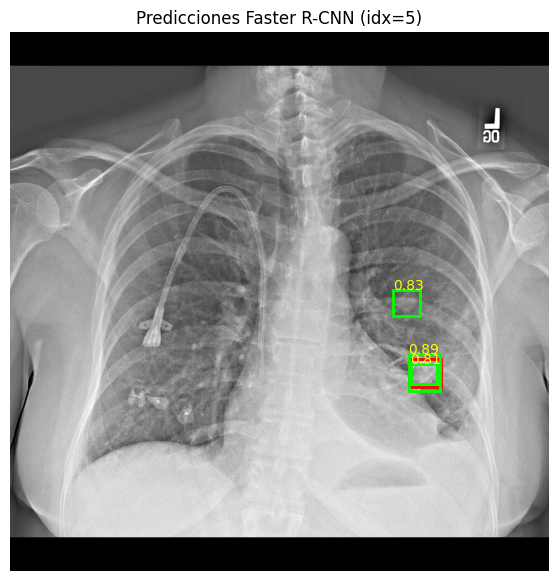

In [ ]:
show_prediction_2(model, train_dataset, 5,0.8)